## Alex's salience 

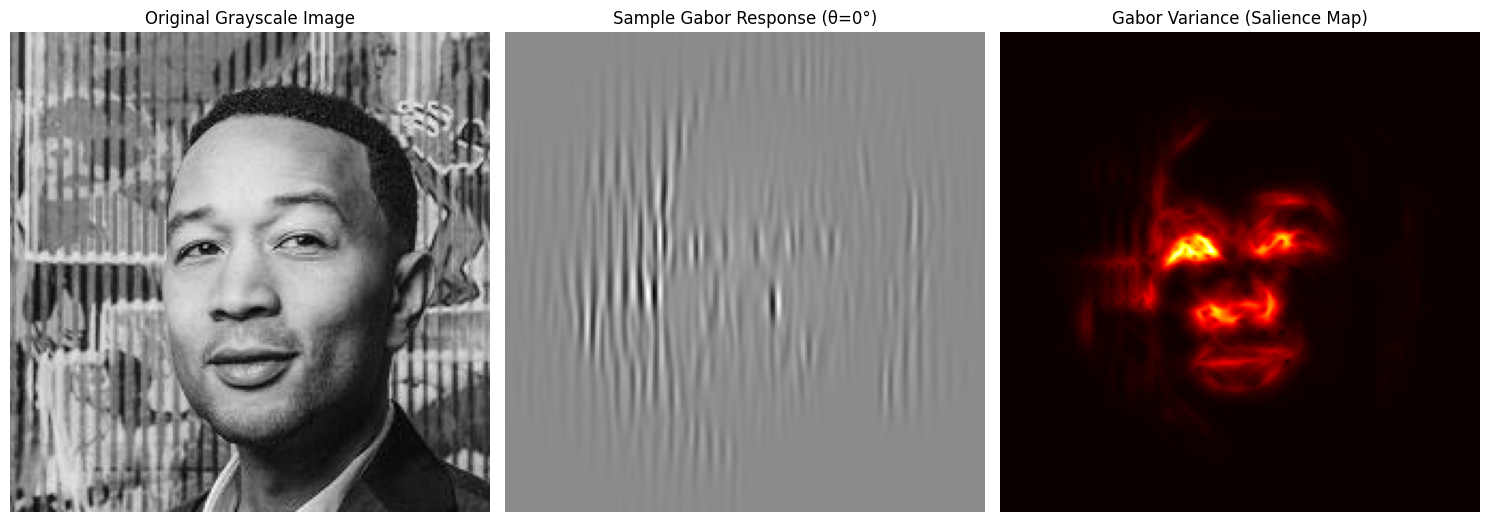

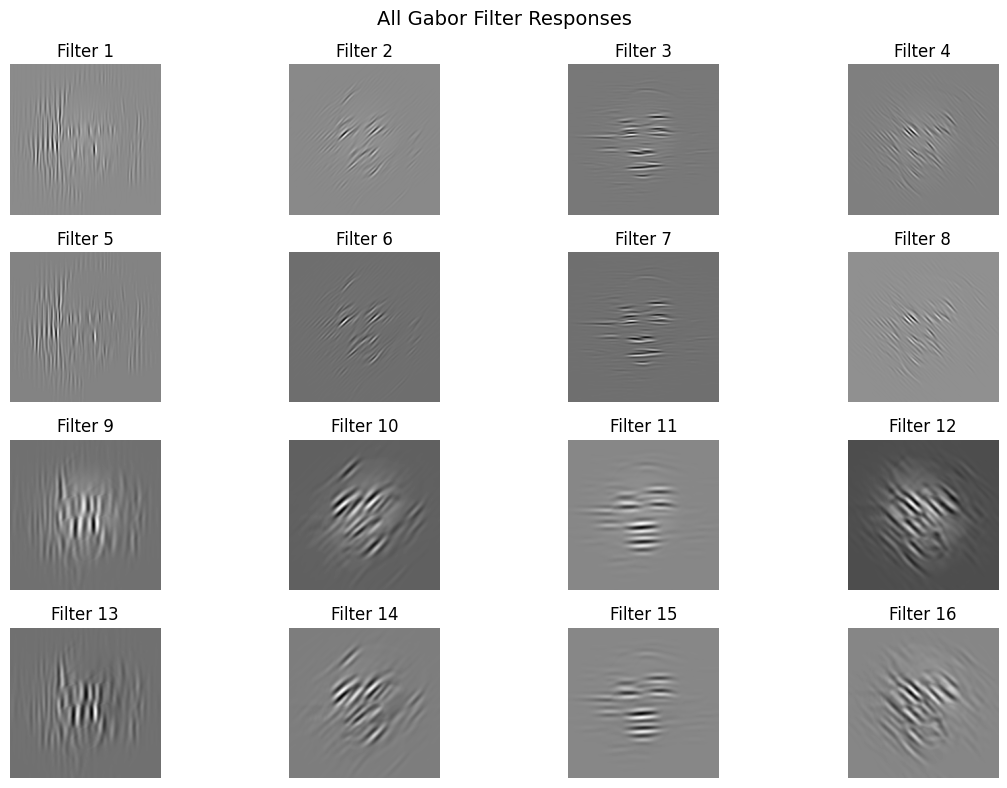

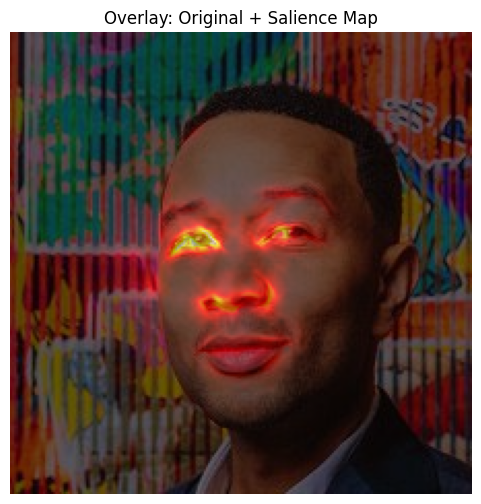

In [26]:
# ===========================
# Based on Alex's original pipeline (kept intact for Gabor + variance logic)
# ===========================

import os
from pathlib import Path
import cv2
import torch
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

# ===========================
# 🧩 Gabor Salience Pipeline (no foveate / logpolar)
# ===========================
class SaliencePipeline:
    def __init__(self, img_size=224, num_salient_points=4):
        self.img_size = img_size
        self.num_salient_points = num_salient_points
        self.kernels = self.get_kernels()
        self.num_kernels = len(self.kernels)

    # Get kernels for gabor filters, each in different direction TODO: test out reducing the number of these!
    def get_kernels(self):
        """Create a Gabor filter bank exactly as in your original code"""
        kernels = []
        size = (31, 31)
        lambd = [5.0, 11.0]
        sigma = [0.56 * l for l in lambd]
        psi = [0.0, np.pi / 2] # without both it has 2 lines, more wavy
        theta = [0.0, np.pi/4, 2*np.pi/4, 3*np.pi/4] #4*np.pi/4,5*np.pi/4,6*np.pi/4,7*np.pi/4] #could probably remove second half
        gamma = 0.5

        for l in range(len(lambd)):
            for p in range(len(psi)):
                for t in range(len(theta)):
                    kernels.append(cv2.getGaborKernel(size, sigma[l], theta[t], lambd[l], gamma, psi[p]))
        return kernels

    def compute_salience_map(self, img_bgr, visualize=True):
        """Compute Gabor variance-based salience map"""
        h, w, _ = img_bgr.shape
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
        img_gray = (img_gray - img_gray.min()) / (img_gray.max() - img_gray.min())

        # Gaussian weighting (center bias)  # gaussian mask
        center_x, center_y = w / 2 - 0.5, h / 2 - 0.5
        x = torch.arange(0, w, dtype=torch.float32)
        y = torch.arange(0, h, dtype=torch.float32)
        y_grid, x_grid = torch.meshgrid(y, x, indexing='ij')
        gaussian_mask = torch.exp(-((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * (w/6)**2))
        weighted_img = gaussian_mask.numpy() * img_gray

        # Normalize weighted image
        weighted_img = (weighted_img - weighted_img.min()) / (weighted_img.max() - weighted_img.min())

        # Apply Gabor filters
        filtered = []
        for i, kernel in enumerate(self.kernels):
            f = cv2.filter2D(np.array(weighted_img), cv2.CV_32F, kernel)
            f = (f - np.mean(f)) / (np.std(f) + 1e-8)
            filtered.append(f)

        # seems to do worse
        # mag = []
        # for i in range(self.num_kernels//2):
        #     mag.append(np.sqrt(filtered[i]**2 + filtered[i+self.num_kernels//2]**2))
        # calculate variance
        # Variance across filter responses
        variance = torch.var(torch.from_numpy(np.array(filtered, dtype=np.float32)), dim=0)
        variance = (variance - variance.min()) / (variance.max() - variance.min())
        variance_np = variance.numpy()

        if visualize:
            self.visualize(img_gray, filtered, variance_np)

        return variance_np

    def visualize(self, img_gray, filtered, variance_np):
        """Visualize key processing stages"""
        plt.figure(figsize=(15, 6))

        # 1. Original
        plt.subplot(1, 3, 1)
        plt.imshow(img_gray, cmap='gray')
        plt.title("Original Grayscale Image")
        plt.axis('off')

        # 2. Representative Gabor response
        plt.subplot(1, 3, 2)
        plt.imshow(filtered[0], cmap='gray')
        plt.title("Sample Gabor Response (θ=0°)")
        plt.axis('off')

        # 3. Salience (Variance)
        plt.subplot(1, 3, 3)
        plt.imshow(variance_np, cmap='hot')
        plt.title("Gabor Variance (Salience Map)")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # Optional: visualize all Gabor responses in a grid
        n_filters = len(filtered)
        cols = 4
        rows = int(np.ceil(n_filters / cols))
        plt.figure(figsize=(12, 8))
        for i in range(n_filters):
            plt.subplot(rows, cols, i+1)
            plt.imshow(filtered[i], cmap='gray')
            plt.title(f"Filter {i+1}")
            plt.axis('off')
        plt.suptitle("All Gabor Filter Responses", fontsize=14)
        plt.tight_layout()
        plt.show()


# ===========================
# 📸 Run pipeline on your image
# ===========================

img_path = '545.jpg'  # Your face image
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found: {img_path}")

# Load
image_bgr = cv2.imread(img_path)
pipeline = SaliencePipeline()
sal_map = pipeline.compute_salience_map(image_bgr, visualize=True)

# ===========================
# Optional: overlay salience map on original
# ===========================
alpha = 0.6
overlay = cv2.cvtColor((image_bgr / 255.0).astype(np.float32), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.imshow(sal_map, cmap='hot', alpha=alpha)
plt.title("Overlay: Original + Salience Map")
plt.axis('off')
plt.show()

## Xavier's code 

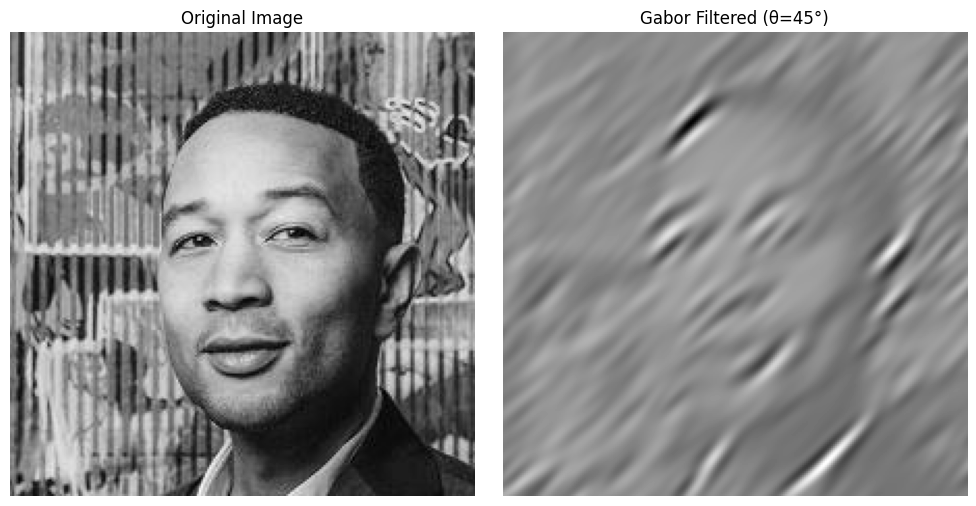

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Define Gabor filter parameters
# -------------------------------
ksize = (31, 31)   # Kernel size
sigma = 4.0        # Standard deviation of the Gaussian envelope
theta = np.pi / 4  # Orientation (45 degrees)
lamda = 10.0       # Wavelength
gamma = 0.5        # Spatial aspect ratio
psi = 0.0          # Phase offset

# -------------------------------
# Create Gabor kernel
# -------------------------------
gabor_kernel = cv2.getGaborKernel(
    ksize=ksize,
    sigma=sigma,
    theta=theta,
    lambd=lamda,
    gamma=gamma,
    psi=psi,
    ktype=cv2.CV_32F
)

# -------------------------------
# Load and preprocess image
# -------------------------------
image_path = "545.jpg"   # Change this to your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Could not read image at {image_path}")

image_float = np.float32(image)

# -------------------------------
# Apply Gabor filter
# -------------------------------
filtered_image = cv2.filter2D(image_float, cv2.CV_32F, gabor_kernel)

# Normalize for display
filtered_norm = cv2.normalize(filtered_image, None, 0, 255, cv2.NORM_MINMAX)
filtered_norm = np.uint8(filtered_norm)

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Gabor filtered image
plt.subplot(1, 2, 2)
plt.imshow(filtered_norm, cmap='gray')
plt.title(f"Gabor Filtered (θ={theta*180/np.pi:.0f}°)")
plt.axis('off')

plt.tight_layout()
plt.show()


## Xavier's code + Gary's(Cottrell, Yamada) paper combined

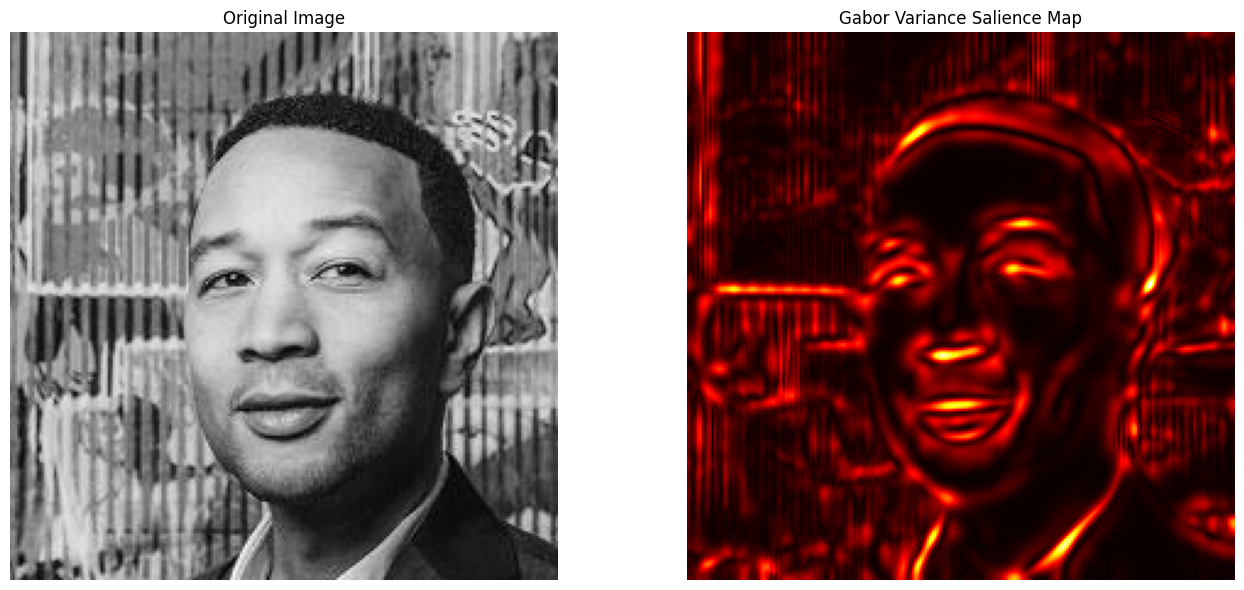

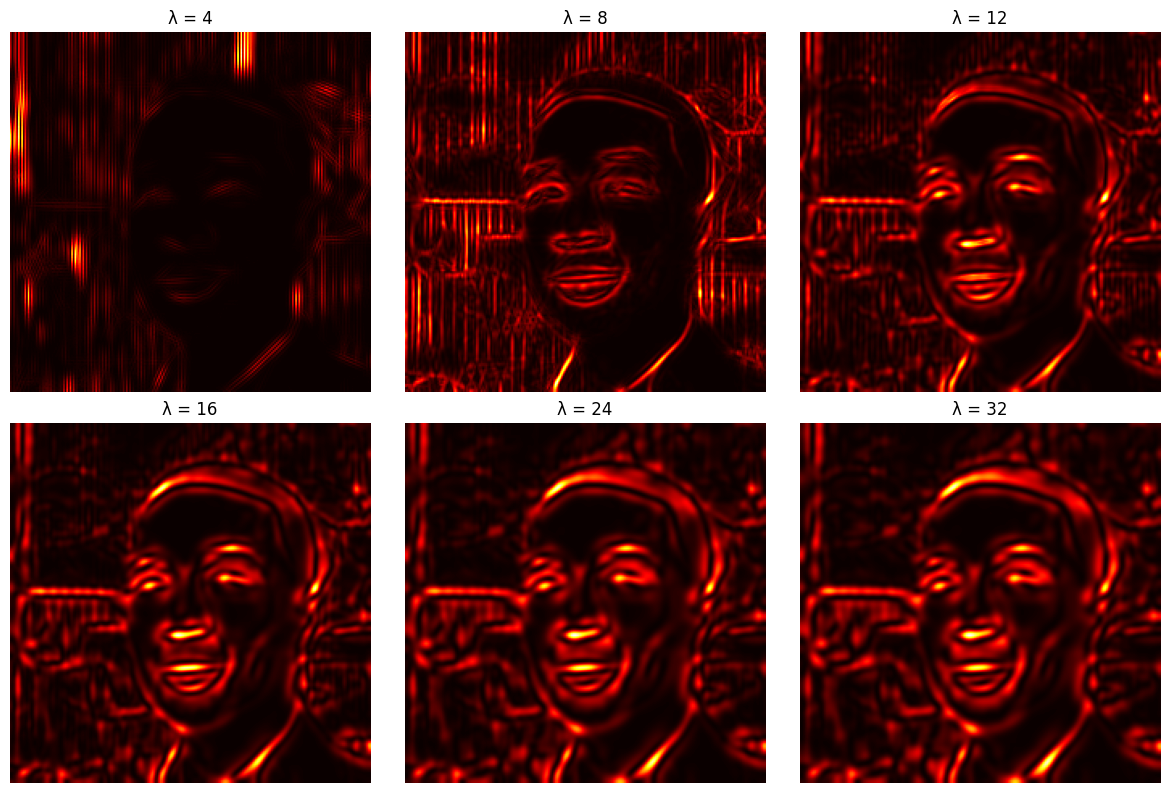

In [19]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Load grayscale image
# ------------------------------------------------
image_path = "545.jpg"   # <-- change this
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Cannot read {image_path}")
img = np.float32(img) / 255.0

# ------------------------------------------------
# 2. Define Gabor bank parameters (as in Yamada & Cottrell 1995)
# ------------------------------------------------
ksize = 31                      # filter size
sigmas = [np.pi]                # sigma ≈ π (paper)
lambdas = [4, 8, 12, 16, 24, 32]  # wavelengths (scales)
thetas = np.linspace(0, np.pi, 8, endpoint=False)  # 8 orientations
gamma = 0.5
psi = 0.0

# ------------------------------------------------
# 3. Build Gabor filter bank and apply to image
# ------------------------------------------------
responses = np.zeros((len(lambdas), len(thetas), *img.shape), dtype=np.float32)

for li, lamda in enumerate(lambdas):
    for ti, theta in enumerate(thetas):
        sigma = np.pi  # per paper
        gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, lamda, gamma, psi, ktype=cv2.CV_32F)
        response = cv2.filter2D(img, cv2.CV_32F, gabor)
        responses[li, ti] = np.abs(response)

# ------------------------------------------------
# 4. Compute variance over orientations (for each wavelength)
# ------------------------------------------------
variance_maps = np.var(responses, axis=1)  # shape = [num_lambdas, H, W]

# Normalize for visualization
variance_maps = (variance_maps - variance_maps.min(axis=(1,2), keepdims=True)) / \
                (variance_maps.max(axis=(1,2), keepdims=True) - variance_maps.min(axis=(1,2), keepdims=True) + 1e-8)

# ------------------------------------------------
# 5. Combine scales (optional: average or weighted sum)
# ------------------------------------------------
salience_map = np.mean(variance_maps, axis=0)
salience_map = (salience_map - salience_map.min()) / (salience_map.max() - salience_map.min() + 1e-8)

# ------------------------------------------------
# 6. Visualization
# ------------------------------------------------
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(salience_map, cmap='hot')
plt.title("Gabor Variance Salience Map")
plt.axis('off')

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 7. (Optional) Inspect per-scale variance maps
# ------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, lamda in enumerate(lambdas):
    axes[i].imshow(variance_maps[i], cmap='hot')
    axes[i].set_title(f"λ = {lamda}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## Nikita's code

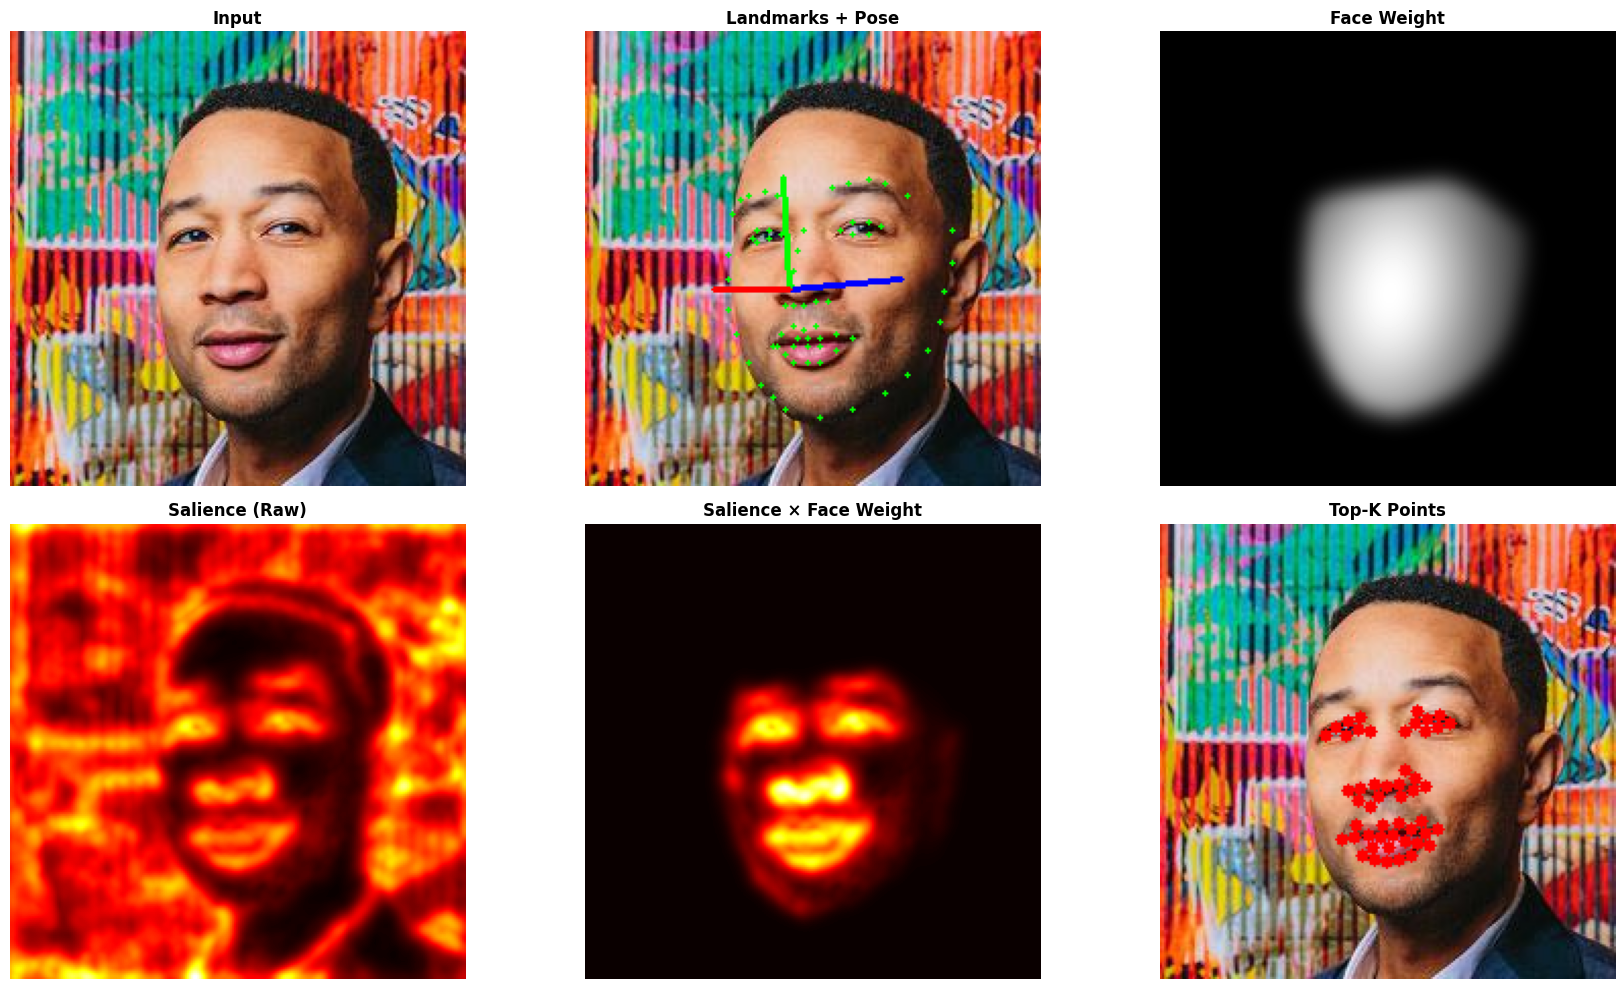

In [27]:
# ==============================================================
# 📘 Visual Salience Pipeline (single image notebook version)
#    Based on your full script, unchanged logic, inline visualization
# ==============================================================

import os, math, cv2, torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from PIL import Image

# ---- Face Alignment (FAN) ----
import face_alignment
from skimage import io as skio

# ---------------- Utils ----------------
def to_gray_float(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.astype(np.float32) / 255.0

def ensure_odd(n):
    return int(n) if int(n) % 2 == 1 else int(n) + 1

def draw_landmarks_and_axes(img_bgr, pts68, rvec=None, tvec=None, K=None):
    out = img_bgr.copy()
    for (x, y) in pts68.astype(int):
        cv2.circle(out, (x, y), 1, (0, 255, 0), -1)
    if rvec is not None and tvec is not None and K is not None:
        axis_len = 60.0
        axes_3d = np.float32([[axis_len,0,0],[0,axis_len,0],[0,0,axis_len]]).reshape(-1,3)
        origin_3d = np.float32([[0,0,0]])
        axes_2d, _ = cv2.projectPoints(axes_3d, rvec, tvec, K, np.zeros(5))
        origin_2d, _ = cv2.projectPoints(origin_3d, rvec, tvec, K, np.zeros(5))
        o = tuple(origin_2d.ravel().astype(int).tolist())
        x = tuple(axes_2d[0].ravel().astype(int).tolist())
        y = tuple(axes_2d[1].ravel().astype(int).tolist())
        z = tuple(axes_2d[2].ravel().astype(int).tolist())
        cv2.line(out, o, x, (255, 0, 0), 2)
        cv2.line(out, o, y, (0, 255, 0), 2)
        cv2.line(out, o, z, (0, 0, 255), 2)
    return out

# ---------------- Head pose via landmarks ----------------
def estimate_head_pose(pts68, img_shape):
    indices = [30, 8, 36, 45, 48, 54]
    image_points = pts68[indices].astype(np.float32)
    model_points = np.array([
        [0.0, 0.0, 0.0],
        [0.0, -63.6, -12.5],
        [-43.3, 32.7, -26.0],
        [43.3, 32.7, -26.0],
        [-28.9, -28.9, -24.1],
        [28.9, -28.9, -24.1]
    ], dtype=np.float32)
    h, w = img_shape[:2]
    focal = w
    center = (w/2, h/2)
    K = np.array([[focal, 0, center[0]],
                  [0, focal, center[1]],
                  [0, 0, 1]], dtype=np.float32)
    success, rvec, tvec = cv2.solvePnP(model_points, image_points, K, np.zeros(5), flags=cv2.SOLVEPNP_ITERATIVE)
    if not success:
        return None, None, None
    return rvec, tvec, K

# ---------------- Face mask + anisotropic Gaussian ----------------
def face_mask_from_landmarks(shape, pts68, blur=21):
    h, w = shape[:2]
    hull = ConvexHull(pts68)
    poly = pts68[hull.vertices].astype(np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, poly, 255)
    if blur > 0:
        mask = cv2.GaussianBlur(mask, (ensure_odd(blur), ensure_odd(blur)), 0)
    return mask.astype(np.float32) / 255.0

def anisotropic_gaussian_window(h, w, center, sigma_x, sigma_y, theta_rad):
    y, x = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    x = x.float(); y = y.float()
    cx, cy = center
    xr, yr = x - cx, y - cy
    c, s = math.cos(theta_rad), math.sin(theta_rad)
    x_rot = c*xr + s*yr
    y_rot = -s*xr + c*yr
    g = torch.exp(-0.5*((x_rot/sigma_x)**2 + (y_rot/sigma_y)**2))
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    return g

# ---------------- Gabor filters ----------------
def gabor_kernel_torch(ks, wavelength, theta, sigma=None, gamma=0.5, phase=0.0):
    ks = ensure_odd(ks)
    grid = torch.arange(ks) - ks//2
    y, x = torch.meshgrid(grid, grid, indexing='ij')
    x = x.float(); y = y.float()
    c, s = math.cos(theta), math.sin(theta)
    x_theta = x*c + y*s
    y_theta = -x*s + y*c
    if sigma is None:
        sigma = 0.56 * wavelength
    gb = torch.exp(-(x_theta**2 + (gamma**2)*(y_theta**2)) / (2*(sigma**2))) * torch.cos(2*math.pi*x_theta/wavelength + phase)
    return gb - gb.mean()

def gabor_energy_bank_torch(img_t, wavelengths, n_orient=8, ks=31, gamma=0.5):
    _, _, H, W = img_t.shape
    energies = []
    for wl in wavelengths:
        e_orients = []
        for o in range(n_orient):
            theta = o * math.pi / n_orient
            k_even = gabor_kernel_torch(ks, wl, theta, gamma=gamma, phase=0.0).to(img_t.device)
            k_odd  = gabor_kernel_torch(ks, wl, theta, gamma=gamma, phase=math.pi/2).to(img_t.device)
            k_even = k_even.view(1,1,ks,ks)
            k_odd  = k_odd.view(1,1,ks,ks)
            resp_even = F.conv2d(img_t, k_even, padding=ks//2)
            resp_odd  = F.conv2d(img_t, k_odd,  padding=ks//2)
            e = torch.sqrt(resp_even**2 + resp_odd**2 + 1e-8)
            e_orients.append(e)
        e_orients = torch.stack(e_orients, dim=0).sum(dim=0)
        energies.append(e_orients[0,0])
    energy_stack = torch.stack(energies, dim=0)
    e_min = energy_stack.amin(dim=(1,2), keepdim=True)
    e_max = energy_stack.amax(dim=(1,2), keepdim=True)
    return (energy_stack - e_min) / (e_max - e_min + 1e-8)

# ---------------- Top-K salience ----------------
def topk_points_nms(sal_map, K=50, radius=6):
    H, W = sal_map.shape
    sal = sal_map.copy()
    picked = []
    rad2 = radius*radius
    for _ in range(K):
        idx = np.argmax(sal)
        y, x = divmod(idx, W)
        score = sal[y, x]
        if score <= 0: break
        picked.append((x, y, float(score)))
        yy, xx = np.ogrid[:H,:W]
        mask = (yy - y)**2 + (xx - x)**2 <= rad2
        sal[mask] = 0.0
    return picked


# ==============================================================
# 🧩 Process a single image step-by-step
# ==============================================================

img_path = "545.jpg"   # your face image
device = "cpu"

bgr = cv2.imread(img_path)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device=device)
preds = fa.get_landmarks(rgb)
if not preds or len(preds[0]) < 68:
    raise RuntimeError("No 68-point face detected.")
pts68 = preds[0]

# ---- Head pose ----
rvec, tvec, K = estimate_head_pose(pts68, bgr.shape)
vis_landmarks_axes = draw_landmarks_and_axes(bgr, pts68, rvec, tvec, K)
vis_landmarks_axes = cv2.cvtColor(vis_landmarks_axes, cv2.COLOR_BGR2RGB)

# ---- Face mask + anisotropic Gaussian ----
mask = face_mask_from_landmarks(bgr.shape, pts68, blur=31)
if rvec is not None:
    R, _ = cv2.Rodrigues(rvec)
    roll = math.atan2(R[1,0], R[0,0])
else:
    pts_mean = pts68.mean(axis=0)
    U, S, Vt = np.linalg.svd(pts68 - pts_mean, full_matrices=False)
    major = Vt[0]
    roll = math.atan2(major[1], major[0])
cx, cy = pts68.mean(axis=0)
face_w = pts68[:,0].ptp(); face_h = pts68[:,1].ptp()
sigma_x = max(15.0, 0.35*face_w)
sigma_y = max(15.0, 0.50*face_h)
gwin = anisotropic_gaussian_window(*bgr.shape[:2], (cx, cy), sigma_x, sigma_y, -roll)
weight = torch.from_numpy(mask).float() * gwin
weight = (weight - weight.min()) / (weight.max() - weight.min() + 1e-8)
face_weight = weight.numpy()

# ---- Gabor filters ----
gray = to_gray_float(bgr)
img_t = torch.from_numpy(gray)[None,None,...].float()
energy_stack = gabor_energy_bank_torch(img_t, wavelengths=[5,7,9,11], n_orient=8, ks=31).cpu().numpy()

# ---- Salience maps ----
wl = np.array([5,7,9,11], dtype=np.float32)
inv_w = (1.0 / (wl + 1e-6)); inv_w = inv_w / inv_w.sum()
sal_map = (energy_stack * inv_w[:,None,None]).sum(axis=0)
sal_weighted = (sal_map * face_weight)
sal_weighted = (sal_weighted - sal_weighted.min()) / (sal_weighted.max() - sal_weighted.min() + 1e-8)

# ---- Top-K points ----
pts = topk_points_nms(sal_weighted.astype(np.float32), K=50, radius=6)
overlay = rgb.copy()
for (x, y, s) in pts:
    cv2.circle(overlay, (int(x), int(y)), 3, (255,0,0), -1)

# ==============================================================
# 🎨 Visualization
# ==============================================================

stages = [
    ("Input", rgb),
    ("Landmarks + Pose", vis_landmarks_axes),
    ("Face Weight", face_weight),
    ("Salience (Raw)", sal_map),
    ("Salience × Face Weight", sal_weighted),
    ("Top-K Points", overlay)
]

plt.figure(figsize=(18,10))
for i,(title,img) in enumerate(stages,1):
    plt.subplot(2,3,i)
    if img.ndim==2:
        plt.imshow(img, cmap='hot' if 'Salience' in title else 'gray')
    else:
        plt.imshow(img)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.axis('off')
plt.tight_layout()
plt.show()
